<a href="https://colab.research.google.com/github/kyungeunvoyage/NailFoldExp/blob/main/Stats.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>


[LME Analysis] 30명 분석 중 (Reference: Area A)


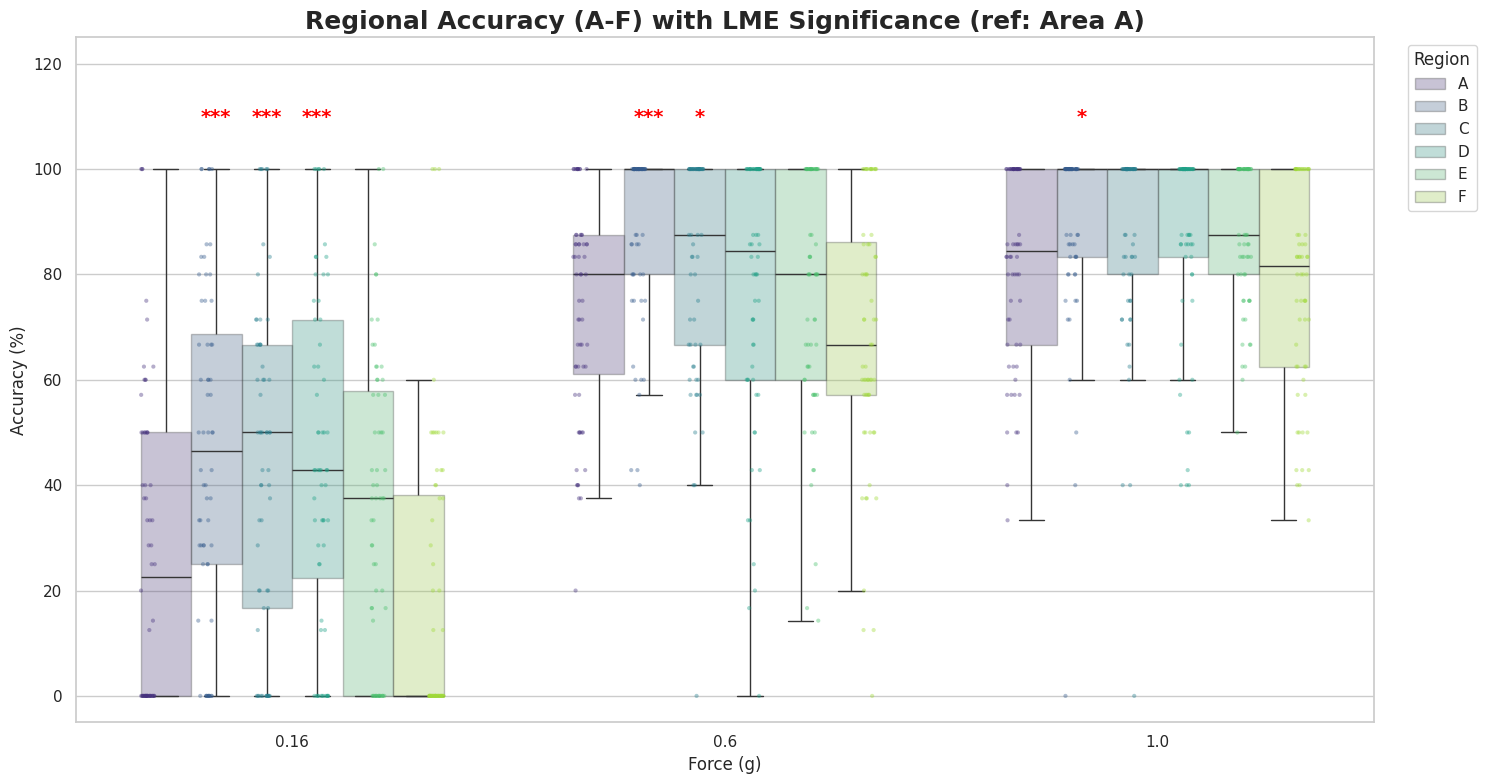

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import glob
import statsmodels.formula.api as smf
import warnings

warnings.filterwarnings('ignore')

# 1. 데이터 로드 및 통합
file_pattern = 'P*_AbsoluteThresholdDetection.csv'
all_files = glob.glob(file_pattern)

if not all_files:
    print("CSV 파일을 찾을 수 없습니다.")
else:
    df_list = [pd.read_csv(f) for f in all_files]
    df = pd.concat(df_list, ignore_index=True)
    sub_col = 'SubjectID' if 'SubjectID' in df.columns else 'Subject'

    # 전처리 및 Score 계산
    df['Force_Val'] = df['Force'].str.extract(r'(\d+\.?\d*)').astype(float)
    df['Condition'] = df['Condition'].str.strip().replace({'Active': 'On-touch (Mid)', 'On-touch (Hard)': 'On-touch (Mid)'})

    def calc_relative_score(row):
        if row['Response'] == 0: return 0
        if row['Target'] == 0: return 100 if row['Response'] == 0 else 0
        error_ratio = abs(row['Target'] - row['Response']) / row['Target']
        return max(0, (1 - error_ratio) * 100)

    df['Relative_Score'] = df.apply(calc_relative_score, axis=1)

    # 분석 대상 필터링
    target_forces = [0.16, 0.6, 1.0]
    areas = ['A', 'B', 'C', 'D', 'E', 'F']
    df_analysis = df[(df['Condition'] == 'On-touch (Mid)') &
                     (df['Force_Val'].isin(target_forces)) &
                     (df['Area'].isin(areas))].copy()

    # --- 시각화 설정 ---
    plt.figure(figsize=(15, 8))
    sns.set_theme(style="whitegrid")

    # 박스플롯 (배경)
    ax = sns.boxplot(
        data=df_analysis, x='Force_Val', y='Relative_Score', hue='Area',
        hue_order=areas, palette="viridis", width=0.7, boxprops=dict(alpha=0.3), fliersize=0
    )
    # 개별 포인트 (Dodge=True로 박스 위치와 일치시킴)
    sns.stripplot(
        data=df_analysis, x='Force_Val', y='Relative_Score', hue='Area',
        hue_order=areas, dodge=True, palette="viridis", alpha=0.4, size=3, ax=ax, legend=False
    )

    # --- LME 분석 및 별표(Asterisk) 추가 로직 ---
    # Seaborn 박스플롯의 각 영역별 중심 x좌표 계산
    n_areas = len(areas)
    width = 0.7
    offsets = np.linspace(-width/2 + width/(2*n_areas), width/2 - width/(2*n_areas), n_areas)

    print(f"\n[LME Analysis] {df_analysis[sub_col].nunique()}명 분석 중 (Reference: Area A)")

    for i, f_val in enumerate(target_forces):
        subset = df_analysis[df_analysis['Force_Val'] == f_val]

        try:
            # LME 모델 실행 (Paired)
            model = smf.mixedlm("Relative_Score ~ Area", subset, groups=subset[sub_col])
            result = model.fit()

            # 각 Area(B~F)를 Area A와 비교
            for j, area in enumerate(areas):
                if area == 'A': continue # 기준점 제외

                term = f"Area[T.{area}]"
                if term in result.pvalues:
                    p_val = result.pvalues[term]

                    # 유의미한 경우 별표 표시
                    if p_val < 0.05:
                        star = '*' if p_val >= 0.01 else '**' if p_val >= 0.001 else '***'
                        # x좌표 = Force 위치(i) + 영역별 오프셋(offsets[j])
                        x_pos = i + offsets[j]
                        ax.text(x_pos, 108, star, ha='center', va='bottom',
                                fontsize=14, fontweight='bold', color='red')
        except:
            continue

    plt.title('Regional Accuracy (A-F) with LME Significance (ref: Area A)', fontsize=18, fontweight='bold')
    plt.ylabel('Accuracy (%)')
    plt.xlabel('Force (g)')
    plt.ylim(-5, 125) # 별표 자리를 위해 y축 상단 확보
    plt.legend(title='Region', bbox_to_anchor=(1.02, 1), loc='upper left')
    plt.tight_layout()
    plt.show()

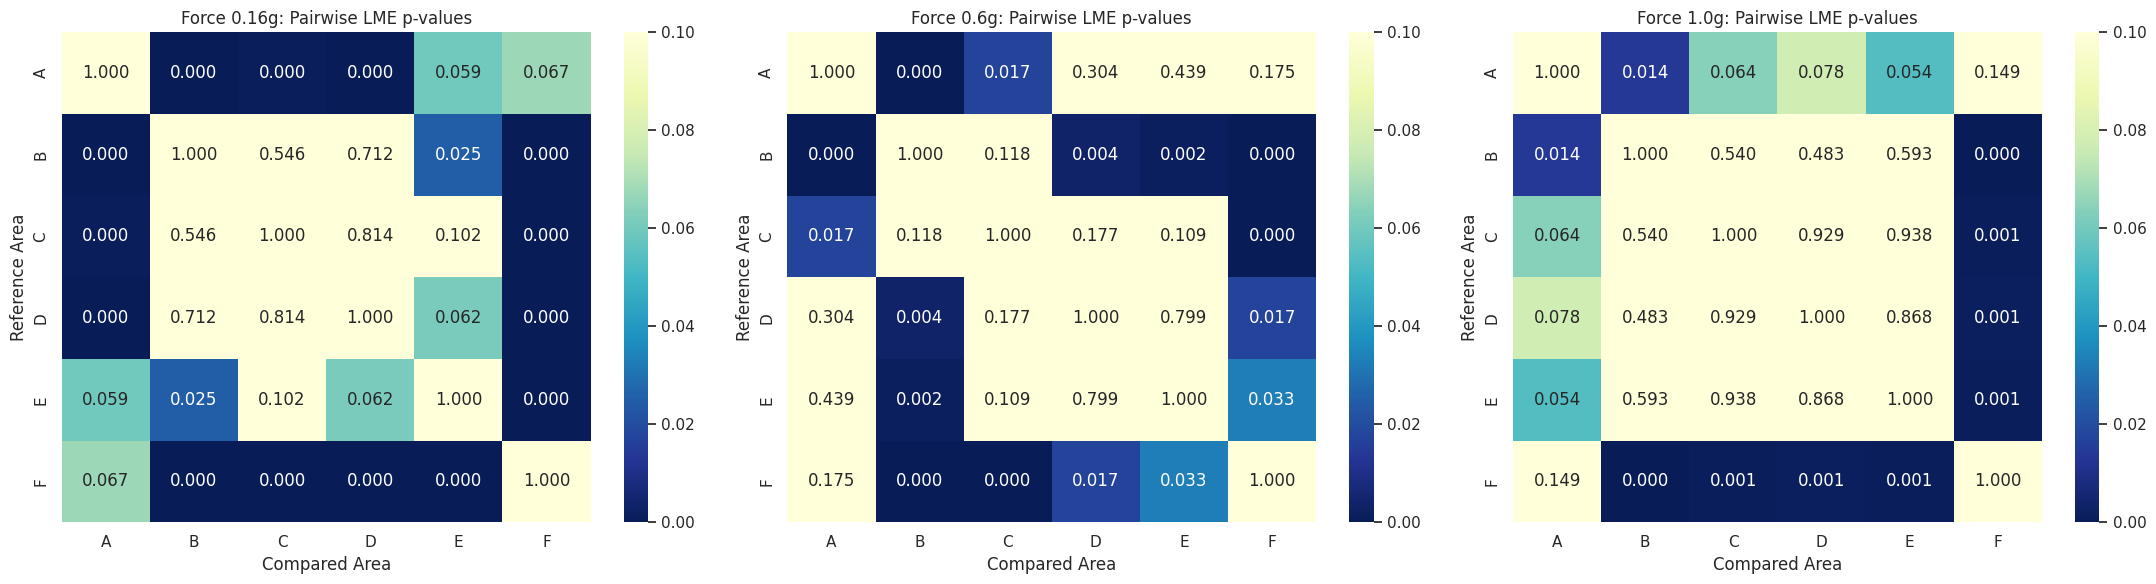

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import statsmodels.formula.api as smf

# 모든 영역 리스트
areas = ['A', 'B', 'C', 'D', 'E', 'F']
target_forces = [0.16, 0.6, 1.0]

# p-value를 저장할 딕셔너리
all_p_matrices = {}

for f_val in target_forces:
    subset = df_analysis[df_analysis['Force_Val'] == f_val]
    # 6x6 빈 행렬 생성
    p_matrix = pd.DataFrame(np.nan, index=areas, columns=areas)

    # 각 Area를 순회하며 기준점(Reference)으로 설정
    for ref_area in areas:
        try:
            # formula 내에서 Treatment reference를 직접 변경
            formula = f"Relative_Score ~ C(Area, Treatment(reference='{ref_area}'))"
            model = smf.mixedlm(formula, subset, groups=subset[sub_col])
            result = model.fit()

            # 기준점 대비 다른 영역들의 p-value 추출
            for target_area in areas:
                if ref_area == target_area:
                    p_matrix.loc[ref_area, target_area] = 1.0 # 자기 자신
                else:
                    col_name = f"C(Area, Treatment(reference='{ref_area}'))[T.{target_area}]"
                    if col_name in result.pvalues:
                        p_matrix.loc[ref_area, target_area] = result.pvalues[col_name]
        except:
            continue
    all_p_matrices[f_val] = p_matrix

# --- 시각화: p-value Heatmap ---
fig, axes = plt.subplots(1, 3, figsize=(22, 6))

for i, f_val in enumerate(target_forces):
    # p-value가 0.05 미만인 곳을 강조하기 위해 색상 범위 조절 (vmin=0, vmax=0.05)
    sns.heatmap(all_p_matrices[f_val], annot=True, fmt=".3f", cmap="YlGnBu_r",
                ax=axes[i], vmin=0, vmax=0.1)
    axes[i].set_title(f'Force {f_val}g: Pairwise LME p-values')
    axes[i].set_xlabel('Compared Area')
    axes[i].set_ylabel('Reference Area')

plt.tight_layout()
plt.show()

In [ ]:
import pandas as pd
import numpy as np
import statsmodels.formula.api as smf
import warnings

warnings.filterwarnings('ignore')

# --- 1. 데이터 분석 및 전체 페어 로깅 ---
all_results = []
areas = ['A', 'B', 'C', 'D', 'E', 'F']
target_forces = [0.16, 0.6, 1.0]

print(f"📊 [Full Pairwise LME Analysis Report] N={df_analysis[sub_col].nunique()}")
print("이 리스트는 유의성 여부와 상관없이 모든 조합의 결과를 포함합니다.")
print("=" * 80)

for f_val in target_forces:
    subset = df_analysis[df_analysis['Force_Val'] == f_val]
    print(f"\n▶ Force Level: {f_val}g 분석 결과")
    print("-" * 50)

    for i in range(len(areas)):
        ref_area = areas[i]
        try:
            # 기준점(Reference)을 순차적으로 변경하며 LME 실행
            formula = f"Relative_Score ~ C(Area, Treatment(reference='{ref_area}'))"
            model = smf.mixedlm(formula, subset, groups=subset[sub_col])
            result = model.fit()

            # 기준점(ref_area)보다 인덱스가 큰 영역들만 비교 (중복 제거)
            for j in range(i + 1, len(areas)):
                target_area = areas[j]
                term = f"C(Area, Treatment(reference='{ref_area}'))[T.{target_area}]"

                if term in result.pvalues:
                    p_val = result.pvalues[term]

                    # 유의성 여부에 따른 별표 처리 (없으면 공백)
                    if p_val < 0.001: star = '***'
                    elif p_val < 0.01: star = '**'
                    elif p_val < 0.05: star = '*'
                    else: star = '(ns)' # non-significant

                    # 모든 결과 로깅
                    log_msg = f"   {ref_area} vs {target_area} : p = {p_val:.4f} {star}"
                    print(log_msg)

                    # 리스트에 저장
                    all_results.append({
                        'Force': f_val,
                        'Comparison': f"{ref_area} vs {target_area}",
                        'p-value': p_val,
                        'Significance': star
                    })
        except Exception as e:
            print(f"   [Error] {ref_area} vs {areas[i+1:]} 분석 중 오류: {e}")

print("\n" + "=" * 80)
print(f"✅ 총 {len(all_results)}개의 페어 분석이 완료되었습니다.")

# --- 2. 결과를 DataFrame으로 변환 (엑셀이나 CSV로 저장 가능) ---
full_summary_df = pd.DataFrame(all_results)
#full_summary_df.to_csv("All_Pairwise_LME_Results.csv", index=False)

📊 [Full Pairwise LME Analysis Report] N=30
이 리스트는 유의성 여부와 상관없이 모든 조합의 결과를 포함합니다.

▶ Force Level: 0.16g 분석 결과
--------------------------------------------------
   A vs B : p = 0.0000 ***
   A vs C : p = 0.0004 ***
   A vs D : p = 0.0002 ***
   A vs E : p = 0.0595 (ns)
   A vs F : p = 0.0673 (ns)
   B vs C : p = 0.5455 (ns)
   B vs D : p = 0.7123 (ns)
   B vs E : p = 0.0253 *
   B vs F : p = 0.0000 ***
   C vs D : p = 0.8137 (ns)
   C vs E : p = 0.1025 (ns)
   C vs F : p = 0.0000 ***
   D vs E : p = 0.0617 (ns)
   D vs F : p = 0.0000 ***
   E vs F : p = 0.0002 ***

▶ Force Level: 0.6g 분석 결과
--------------------------------------------------
   A vs B : p = 0.0001 ***
   A vs C : p = 0.0174 *
   A vs D : p = 0.3039 (ns)
   A vs E : p = 0.4390 (ns)
   A vs F : p = 0.1749 (ns)
   B vs C : p = 0.1177 (ns)
   B vs D : p = 0.0036 **
   B vs E : p = 0.0015 **
   B vs F : p = 0.0000 ***
   C vs D : p = 0.1772 (ns)
   C vs E : p = 0.1088 (ns)
   C vs F : p = 0.0002 ***
   D vs E : p = 0.7994 (ns